In [2]:
from matplotlib import pyplot as plt
import re
import json
import pandas as pd

In [3]:
def load_task_and_preprocess(results_file):

    with open(results_file, "r") as f:
        lines = f.readlines()

    list_json = []
    for l in lines:
        list_json.append(json.loads(l))
    df = pd.DataFrame(list_json)

    df["model"] = df["model"].apply(lambda x: x.split("/")[1])
    df["params"] = df["model"].apply(lambda x: re.findall(r"(\d+(?:\.\d+)?[bBmM])", x.upper())[0])
    df["acc_values"] = df.apply(lambda x: x["acc_values"]["acc"] if x["task_name"] == "livecodebench" else x["acc_values"]["smoothed_bleu_4,create_output"], axis=1)
    df = df.reset_index().rename(columns={"acc_values": "acc"})
    df = df[['model', "params", 'task_name', 'acc','cpu_energy', 'gpu_energy', 'energy_consumed', 'ram_energy', 'duration']]
    df["energy_per_instance"] = df.apply(lambda x: x["energy_consumed"] / (150 if x["task_name"] == "livecodebench" else 500), axis=1)
    df_lcb = df[df["task_name"] == "livecodebench"].drop(columns=["task_name"])
    df_c2t = df[df["task_name"] == "code2text_python"].drop(columns=["task_name"])
    merged_df = pd.merge(df_lcb, df_c2t.drop(columns=["params"]), on="model", suffixes=("_lcb", "_c2t"))
    return df_lcb, df_c2t, merged_df.set_index("model")

df_lcb, df_c2t, df_merged = load_task_and_preprocess("../../lm_eval/results/final_results.jsonl")
df_merged.head(3)

,params,acc_lcb,cpu_energy_lcb,gpu_energy_lcb,energy_consumed_lcb,ram_energy_lcb,duration_lcb,energy_per_instance_lcb,acc_c2t,cpu_energy_c2t,gpu_energy_c2t,energy_consumed_c2t,ram_energy_c2t,duration_c2t,energy_per_instance_c2t
model,,,,,,,,,,,,,,,
deepseek-coder-6.7b-base,6.7B,0.073333,302285.1433,9.322687e+05,1.271008e+06,36454.1986,3816.249486,8473.386898,9.388063,295526.9465,913191.3686,1.244315e+06,35596.9561,3732.930564,2488.630542
starcoderbase-1b,1B,0.000000,54141.8734,1.394003e+05,2.000533e+05,6511.1735,683.659286,1333.688969,1.073386,75366.7335,188572.6409,2.730064e+05,9067.0350,952.274569,546.012819
starcoder2-3b,3B,0.006667,351481.5484,1.022866e+06,1.417065e+06,42717.4444,4445.304724,9447.098834,7.640213,280310.5006,797082.8317,1.111347e+06,33953.5027,3538.672109,2222.693670


In [4]:
acc_ene_dur_ratio = pd.DataFrame()
acc_ene_dur_ratio.index = df_merged.index
c2t_acc = (df_merged["acc_c2t"] - df_merged["acc_c2t"].min()) / (df_merged["acc_c2t"].max() - df_merged["acc_c2t"].min())
lcb_acc = (df_merged["acc_lcb"] - df_merged["acc_lcb"].min()) / (df_merged["acc_lcb"].max() - df_merged["acc_lcb"].min())
acc_ene_dur_ratio["acc_c2t_to_lcb_norm"] = c2t_acc / lcb_acc
acc_ene_dur_ratio["energy_c2t_to_lcb"] = df_merged["energy_consumed_c2t"] / df_merged["energy_consumed_lcb"]
acc_ene_dur_ratio["duration_c2t_to_lcb"] = df_merged["duration_c2t"] / df_merged["duration_lcb"]
acc_ene_dur_ratio.to_excel("acc_ene_dur_ratio.xlsx")

In [5]:
import pandas as pd
import re


def parse_cc_log(f_name):
    with open(f_name, "r") as f:
        cc_logs = f.readlines()

    tmp_cc_logs = [
        line
        for line in cc_logs
        if "g.CO2eq/s mean an estimation of" not in line and "WARNING" not in line
    ]
    cc_logs = tmp_cc_logs

    final_rows = []
    for i in range(0, len(cc_logs), 5):
        row_creator = {}
        ram_data_str = cc_logs[i]
        row_creator["ram_energy"], row_creator["ram_power"] = re.findall(
            r"Energy consumed for RAM : ([+-]?\d+(?:\.\d+)?) kWh. RAM Power : ([+-]?\d+(?:\.\d+)?) W",
            ram_data_str,
        )[0]

        cpu_data_str = cc_logs[i + 1]
        row_creator["cpu_energy"], row_creator["cpu_power"] = re.findall(
            r"Delta energy consumed for CPU with intel_rapl : ([+-]?\d+(?:\.\d+)?) kWh, power : ([+-]?\d+(?:\.\d+)?)",
            cpu_data_str,
        )[0]
        row_creator["cpu_timestamp"] = cpu_data_str.split("- codecarbon")[0].strip()

        cumulative_cpu_data_str = cc_logs[i + 2]
        row_creator["cpu_cum_energy"] = re.findall(
            r"Energy consumed for All CPU : ([+-]?\d+(?:\.\d+)?) kWh",
            cumulative_cpu_data_str,
        )[0]

        gpu_data_str = cc_logs[i + 3]
        row_creator["gpu_cum_energy"], row_creator["gpu_power"] = re.findall(
            r"Energy consumed for all GPUs : ([+-]?\d+(?:\.\d+)?) kWh. Total GPU Power : ([+-]?\d+(?:\.\d+)?) W",
            gpu_data_str,
        )[0]

        cumulative_energy_data = cc_logs[i + 4]
        row_creator["cum_energy"] = re.findall(
            r"([+-]?\d+(?:\.\d+)?) kWh of electricity used since the beginning",
            cumulative_energy_data,
        )[0]

        final_rows.append(row_creator)

    df = pd.DataFrame(final_rows)
    df["cpu_timestamp"] = pd.to_datetime(
        df["cpu_timestamp"], format="%Y-%m-%d %H:%M:%S,%f"
    )
    df.set_index("cpu_timestamp", inplace=True)
    df = df.astype("float")
    df["time_diff_sec"] = df.index.to_series().diff().dt.total_seconds()
    energy_cols = [
        "ram_energy",
        "cpu_energy",
        "cpu_cum_energy",
        "gpu_cum_energy",
        "cum_energy",
    ]
    for col in energy_cols:
        df[col] = df[col] * (3.6 * 1e6)

    df["interval_cpu_calculated_energy"] = df["cpu_power"] * df["time_diff_sec"]

    return df

In [6]:
import os
from pathlib import Path

model_name_df_map = {"LiveCodeBench": {}, "CodeXGLUE": {}}
model_names = []
prefix_path = "../../lm_eval/main_codecarbon_log"
for task_name in model_name_df_map.keys():
    for model in os.listdir(f"{prefix_path}/{task_name}_cc_logs"):
        main_dir = Path(f"{prefix_path}/{task_name}_cc_logs")
        model_ii_path = main_dir / model / "instances_inference.log"
        if model_ii_path.exists():
            model_name_df_map[task_name][model] = parse_cc_log(model_ii_path)
        model_names.append(model) if model not in model_names else None

In [7]:
plot_color_1 = "#0E814C"
plot_color_2 = "#144A6E"
plot_color_3 = "#791A0E"

In [8]:
import numpy as np

def plot_power(series, label, color=None, ylim_pad=2, mean=True):

    y = np.asarray(series, dtype=float)
    x = np.arange(len(y))

    fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=150)
    ax.plot(x, y, label=label, color=color, linewidth=2)

    if mean:
        mu = float(np.nanmean(y))
        ax.axhline(mu, linestyle='--', linewidth=1, color='0.5')
        ax.text(0.01, 0.02, f"mean ≈ {mu:.1f} W", transform=ax.transAxes, fontsize=9, color='0.35')

    ax.set_xlabel("Number of Samples")
    ax.set_ylabel("Power (W)")
    leg = ax.legend(frameon=False, loc="lower right")

    ax.grid(True, axis="y", linewidth=0.6, alpha=0.35)
    ax.minorticks_on()
    ax.grid(True, which='minor', axis='y', linewidth=0.4, alpha=0.2)

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    ymin, ymax = np.nanmin(y), np.nanmax(y)
    ax.set_ylim(ymin - ylim_pad, ymax + ylim_pad)
    ax.margins(x=0.01)

    plt.tight_layout()
    return ax


# Creating per model per device powers

In [8]:
for task in model_name_df_map.keys():
    for model in model_names:
        for device in ["cpu", "gpu"]:
            plot_power(
            model_name_df_map[task][model][f"{device}_power"].values,
            label=model,
            color=plot_color_1,
            ylim_pad=1.5
        )
            plt.savefig(f"energy_data/{task}/{device}_powers/{model}.pdf")
            plt.close()


# Plots where we have to line plot of both tasks for the same model

In [9]:
def create_plot(fig, ax, data, color, label):
    ax.plot(data, color=color, label=label)
    ax.set_xlabel("Number of Samples")
    ax.set_ylabel("Power (W)")
    ax.grid(True, axis="y", alpha=0.35)
    ax.minorticks_on()
    ax.grid(True, which="minor", axis="y", alpha=0.2, linewidth=0.6)
    ax.legend(loc="lower right", fontsize=8)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    fig.tight_layout()

In [9]:
colors = [plot_color_1, plot_color_2]
for model in model_names:
    fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=150)
    color_counter = 0
    for task in model_name_df_map.keys():
        create_plot(fig, ax, model_name_df_map[task][model]["gpu_power"].values, colors[color_counter], f"{model}-{task}")
        color_counter += 1
        power_series = model_name_df_map[task][model]["gpu_power"]
        df_merged.loc[model, f"gpu_avg_power_{'lcb' if task == 'LiveCodeBench' else 'c2t'}"] = power_series.mean()

    fig.savefig(f"energy_data/task_gpu_power_comparison/{model}.pdf")
    plt.close()

df_merged["gpu_power_ratio"] = df_merged["gpu_avg_power_c2t"] / df_merged["gpu_avg_power_lcb"]


# GPU Quantiles

In [158]:
for model in model_names:
    for task in model_name_df_map.keys():
        power_series = model_name_df_map[task][model]["gpu_power"]
        first_quantile = power_series.quantile(0.005)
        last_quantile = power_series.quantile(0.995)
        min_quantile = power_series[(power_series > first_quantile) & (power_series < last_quantile)].min()
        max_quantile = power_series[(power_series > first_quantile) & (power_series < last_quantile)].max()
        fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=150)
        create_plot(fig, ax, model_name_df_map[task][model]["gpu_power"].values, color=plot_color_1, label=f"{model}-{task}")
        create_plot(fig, ax, [min_quantile for _ in range(len(power_series))], color=plot_color_2, label=f"High_Quantile")
        create_plot(fig, ax, [max_quantile for _ in range(len(power_series))], color=plot_color_3, label=f"Low_Quantile")
        
        plt.savefig(f"energy_data/{task}/gpu_quantiles/{model}.pdf")
        plt.close()
        

## All model CPU and GPU powers in different plots

In [159]:
for task in model_name_df_map.keys():
    for device in ["cpu", "gpu"]:
        plt.figure(figsize=(12, 9))
        for model in model_names:
            plt.plot(model_name_df_map[task][model][f"{device}_power"].values, label=f"{model}")
        plt.legend()
        plt.savefig(f"energy_data/{task}/{device}_powers_all.pdf")
        plt.close()


In [10]:
final_df = df_merged.join(acc_ene_dur_ratio)

In [16]:
df_merged.to_excel("all_results.xlsx")

# Plot Energy Time Relation

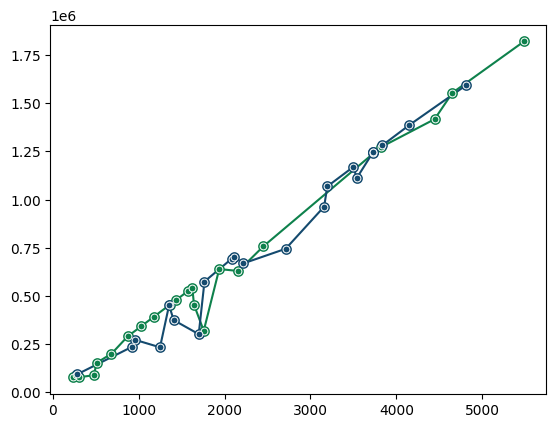

In [177]:
def create_scatter(x, y, color):
    plt.scatter(x, y, s=60, c=color, marker="o", linewidths=0, zorder=4)
    sc = plt.scatter(x, y, s=24, c=color, marker="o",
                edgecolors="white", linewidths=0.7, zorder=5)

lcb_dur, lcb_energy = zip(*sorted(zip(df_lcb["duration"].values, df_lcb["energy_consumed"].values), key=lambda x: x[0]))
c2t_dur, c2t_energy = zip(*sorted(zip(df_c2t["duration"].values, df_c2t["energy_consumed"].values), key=lambda x: x[0]))
plt.plot(lcb_dur, lcb_energy, color=plot_color_1)
plt.plot(c2t_dur, c2t_energy, color=plot_color_2)
create_scatter(lcb_dur, lcb_energy, plot_color_1)
create_scatter(c2t_dur, c2t_energy, plot_color_2)



In [22]:
df_lcb

,model,params,acc,cpu_energy,gpu_energy,energy_consumed,ram_energy,duration,energy_per_instance
0,deepseek-coder-6.7b-base,6.7B,0.073333,302285.1433,9.322687e+05,1.271008e+06,36454.1986,3816.249486,8473.386898
1,starcoderbase-1b,1B,0.000000,54141.8734,1.394003e+05,2.000533e+05,6511.1735,683.659286,1333.688969
2,starcoder2-3b,3B,0.006667,351481.5484,1.022866e+06,1.417065e+06,42717.4444,4445.304724,9447.098834
3,CodeLlama-7b-Instruct-hf,7B,0.066667,92945.4890,2.866602e+05,3.908020e+05,11196.2947,1172.851345,2605.346821
4,Qwen2.5-Coder-3B-Instruct,3B,0.166667,40431.2617,1.075981e+05,1.528595e+05,4830.1210,510.124517,1019.063358
5,Qwen2.5-Coder-7B-Instruct,7B,0.120000,108102.2793,3.336201e+05,4.547970e+05,13074.6008,1364.977220,3031.979999
6,Qwen2.5-Coder-1.5B,1.5B,0.153333,24212.7688,5.093450e+04,7.804291e+04,2895.6441,305.908532,520.286071
7,deepseek-coder-1.3b-base,1.3B,0.033333,130356.8338,3.081601e+05,4.540463e+05,15529.3597,1644.476756,3026.975181
8,deepseek-coder-7b-instruct-v1.5,7B,0.186667,113521.7280,3.512773e+05,4.785250e+05,13725.9815,1435.552632,3190.166651
9,starcoder2-7b,7B,0.013333,368228.2541,1.141197e+06,1.554178e+06,44752.3868,4653.044304,10361.185225


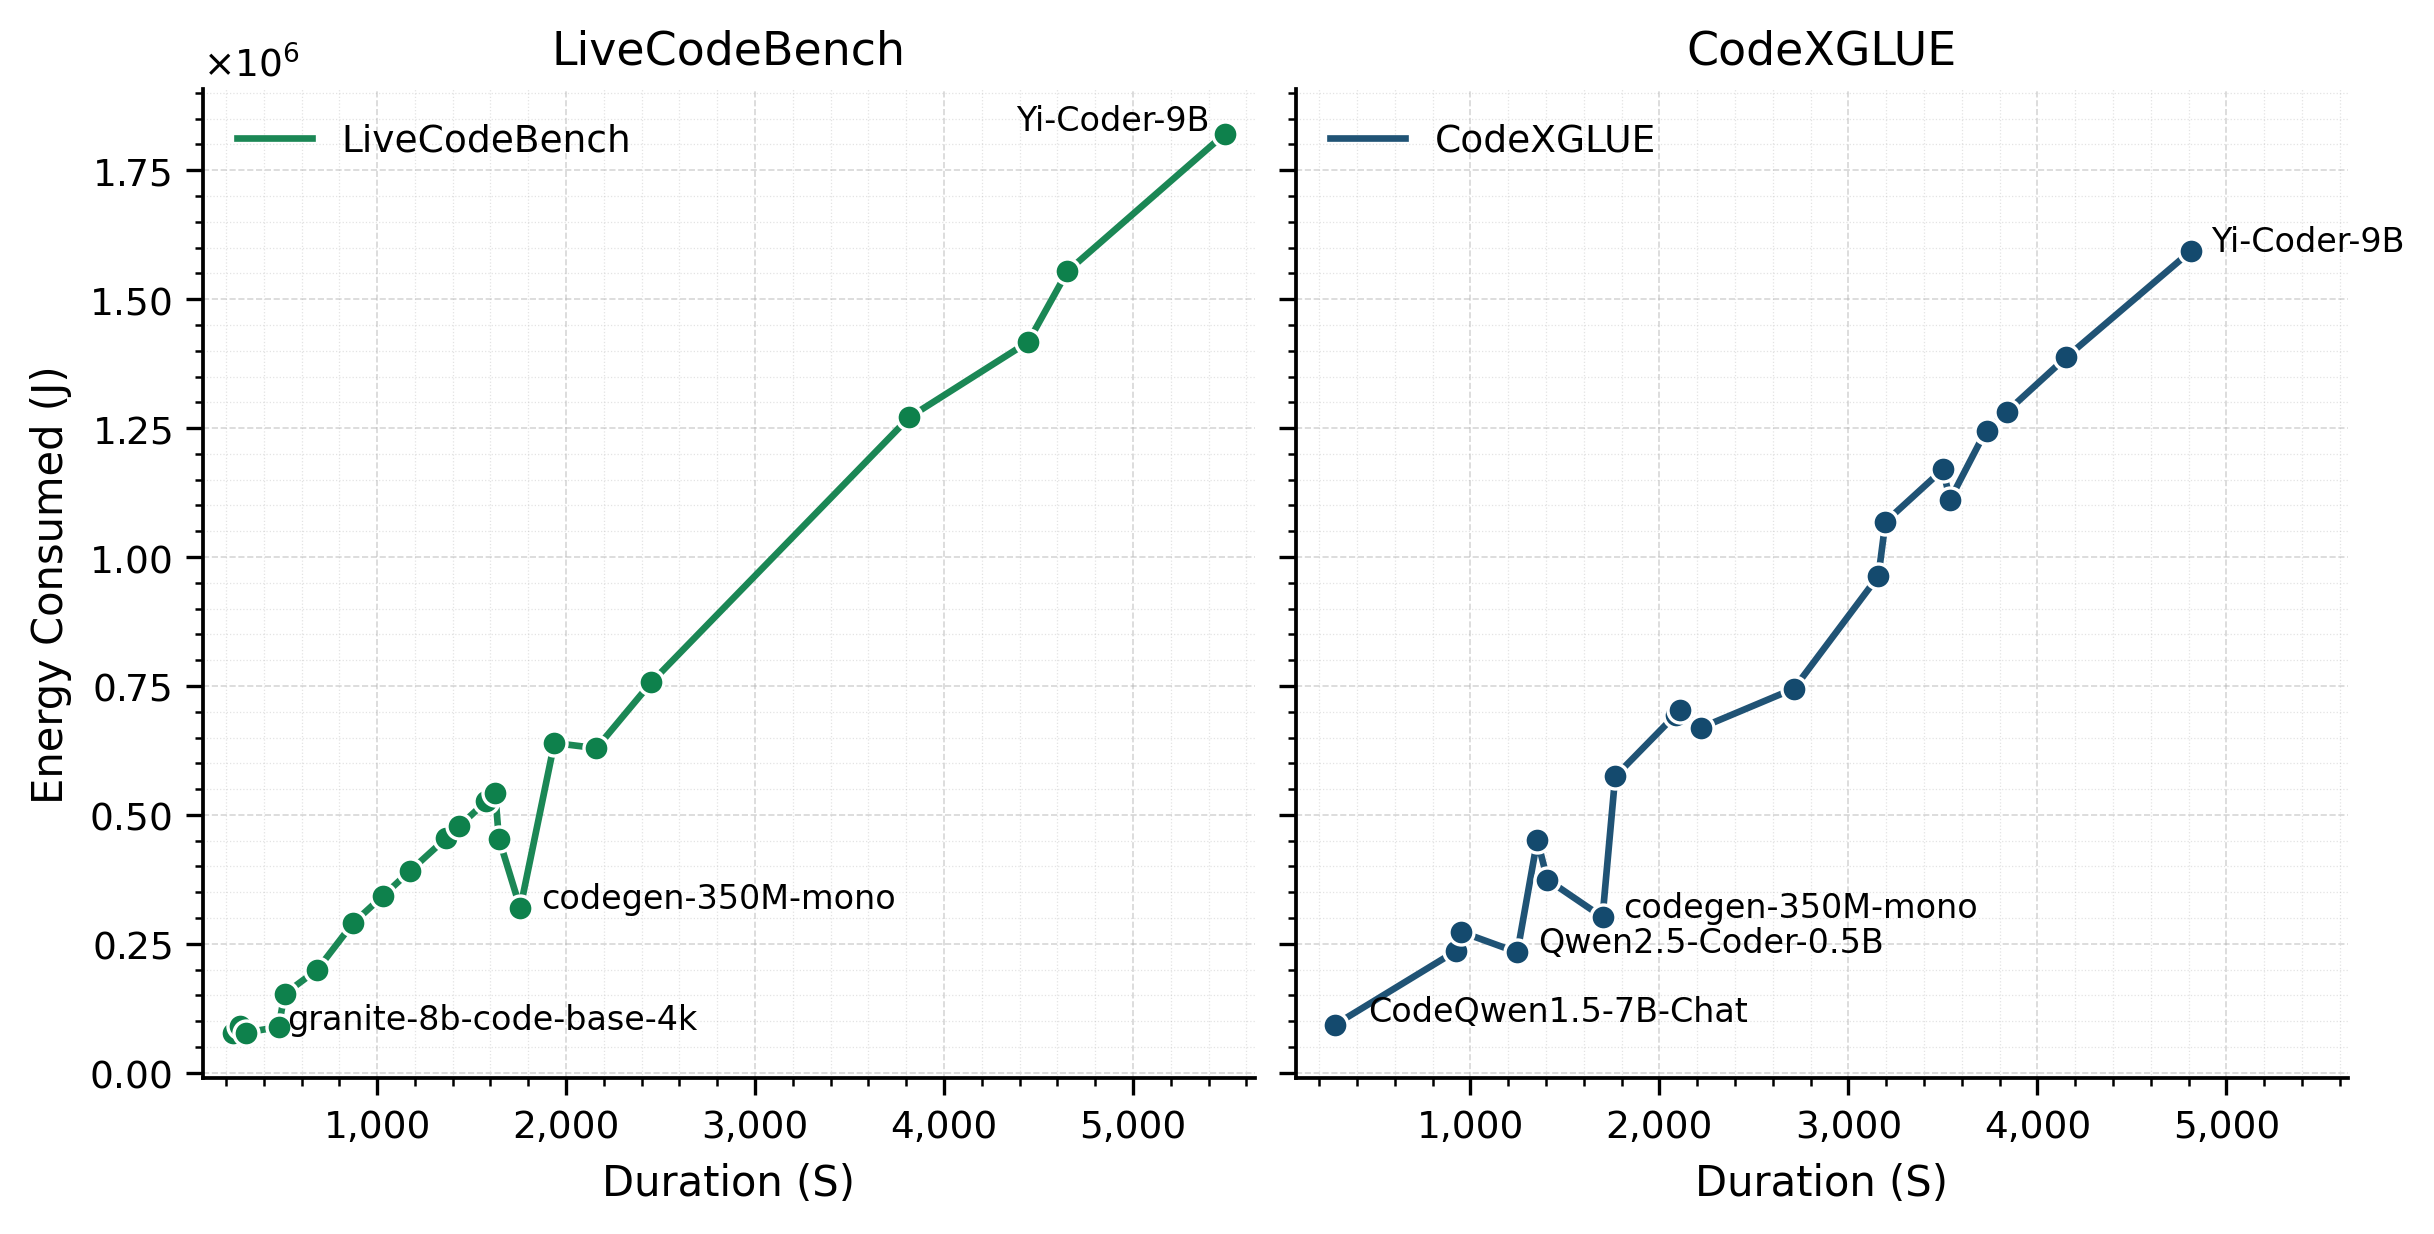

In [44]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FuncFormatter, AutoMinorLocator


annotation_models = {"lcb": [10], "c2t": [11, 10, 12]}


def strange_power_annotation(ax, model_name, duration, energy, position=(5, 0)):
    ax.annotate(model_name, (duration, energy),
                            xytext=position, textcoords="offset points",
                            fontsize=8, color="black", zorder=7)


def nice_axes(ax):
    ax.tick_params(axis='both', which='major', length=4, width=0.8, labelsize=9)
    ax.tick_params(axis='both', which='minor', length=2, width=0.6)
    for s in ['top','right']:
        ax.spines[s].set_visible(False)
    for s in ['left','bottom']:
        ax.spines[s].set_linewidth(0.9)
    ax.grid(True, which='major', linestyle='--', linewidth=0.4, alpha=0.5)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.35)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    sf = ScalarFormatter(useMathText=True); sf.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(sf)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}" if x == int(x) else f"{x:,.0f}"))

def create_series(ax, x, y, color, label=None):
    ax.plot(x, y, color=color, linewidth=1.6, alpha=0.95, zorder=3, label=label)
    ax.scatter(x, y, s=36, c=color, edgecolors='white', linewidths=0.8, zorder=4)

# --- prepare data (sorted) ---
lcb_dur, lcb_energy, lcb_model_names = zip(*sorted(zip(df_lcb["duration"].values, df_lcb["energy_consumed"].values, df_lcb["model"].values)))
c2t_dur, c2t_energy, c2t_model_names = zip(*sorted(zip(df_c2t["duration"].values, df_c2t["energy_consumed"].values, df_c2t["model"].values)))

plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300,
    "font.size": 9, "axes.labelsize": 10, "axes.titlesize": 11,
    "legend.fontsize": 9, "pdf.fonttype": 42, "ps.fonttype": 42
})

# --- two subplots in one row ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=True, layout="compressed")

# spread panels apart a bit (works with constrained_layout=True)
# fig.set_constrained_layout_pads(w_pad=1/72, h_pad=1/72, wspace=0.18, hspace=0.02)
# fig.set_size_inches(8, 4)  # was (7.2, 3.2)

# --- per-axis x limits so each panel uses its full width ---
# LCB
xpad1 = (max(lcb_dur) - min(lcb_dur)) * 0.05
ax1.set_xlim(min(lcb_dur) - xpad1, max(lcb_dur) + xpad1)

# CodeXGLUE
xpad2 = (max(c2t_dur) - min(c2t_dur)) * 0.05
ax2.set_xlim(min(c2t_dur) - xpad2, max(c2t_dur) + xpad2)

for models_ids in annotation_models["lcb"]:
    strange_power_annotation(ax1, df_lcb.iloc[models_ids]["model"], df_lcb.iloc[models_ids]["duration"], df_lcb.iloc[models_ids]["energy_consumed"])

for models_ids in annotation_models["c2t"]:
    strange_power_annotation(ax2, df_c2t.iloc[models_ids]["model"], df_c2t.iloc[models_ids]["duration"], df_c2t.iloc[models_ids]["energy_consumed"])


strange_power_annotation(ax1, df_lcb.iloc[12]["model"], df_lcb.iloc[12]["duration"], df_lcb.iloc[12]["energy_consumed"], position=(-50, 1))
strange_power_annotation(ax1, df_lcb.iloc[20]["model"], df_lcb.iloc[20]["duration"], df_lcb.iloc[20]["energy_consumed"], position=(13, 1))
strange_power_annotation(ax2, df_c2t.iloc[18]["model"], df_c2t.iloc[18]["duration"], df_c2t.iloc[18]["energy_consumed"], position=(8, 1))

# keep a shared y for fair comparison
y_all = lcb_energy + c2t_energy
ypad = (max(y_all) - min(y_all)) * 0.05
for ax in (ax1, ax2):
    ax.set_ylim(min(y_all) - ypad, max(y_all) + ypad)


create_series(ax1, lcb_dur, lcb_energy, plot_color_1, label="LiveCodeBench")
ax1.set_title("LiveCodeBench")
ax1.set_xlabel("Duration (S)")
ax1.set_ylabel("Energy Consumed (J)")
nice_axes(ax1)
ax1.legend(frameon=False, loc="upper left")

create_series(ax2, c2t_dur, c2t_energy, plot_color_2, label="CodeXGLUE")
ax2.set_title("CodeXGLUE")
ax2.set_xlabel("Duration (S)")
nice_axes(ax2)
ax2.legend(frameon=False, loc="upper left")

# consistent padding
x_all = lcb_dur + c2t_dur
y_all = lcb_energy + c2t_energy
xpad = (max(x_all) - min(x_all)) * 0.03
ypad = (max(y_all) - min(y_all)) * 0.05
for ax in (ax1, ax2):
    ax.set_xlim(min(x_all) - xpad, max(x_all) + xpad)
    ax.set_ylim(min(y_all) - ypad, max(y_all) + ypad)

plt.savefig("energy_vs_duration_1x2.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
